In [1]:
## IMPORTS ##

!pip install pytorch-lightning

import os, shutil, cv2, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn

import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from pytorch_lightning.loggers import CSVLogger

import albumentations as A
from albumentations.pytorch.transforms import ToTensorV2

from torch.utils.data import Dataset, DataLoader
from torchvision import models
from torchmetrics.classification import BinaryAccuracy, BinaryAUROC

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

In [2]:
## reproducibility ##

SEED = 42
pl.seed_everything(SEED, workers=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Seed set to 42


Using device: cuda


In [3]:
# Paths
KAGGLE_DIR = '/kaggle/input/datasets/nazmul0087/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone'
BASE_DATA_DIR = '/kaggle/working/kidney_data_organized'

ARTIFACT_DIR = "artifacts"

os.makedirs(ARTIFACT_DIR, exist_ok=True)


In [4]:
def organize_data(kaggle_dir_path):
    # deleting the subfolder
    if os.path.exists(BASE_DATA_DIR):
        print(f"Cleaning existing organized data at {BASE_DATA_DIR}...")
        shutil.rmtree(BASE_DATA_DIR)
    
    # creating the structure
    for split in ['train', 'val', 'test']:
        for c in ['healthy', 'abnormal']:
            os.makedirs(os.path.join(BASE_DATA_DIR, split, c), exist_ok=True)

    mapping = {"Normal":'healthy', "Cyst":'abnormal', "Stone":'abnormal', "Tumor":'abnormal'}
    
    for source_folder, target_class in mapping.items():
        src_path = os.path.join(kaggle_dir_path, source_folder)
        if not os.path.exists(src_path): 
            continue

        images = [f for f in os.listdir(src_path) if f.lower().endswith(('.png','.jpg','.jpeg'))]
        
        # Split logic (80/10/10)
        train_f, temp_f = train_test_split(images, test_size=0.2, random_state=42)
        val_f, test_f = train_test_split(temp_f, test_size=0.5, random_state=42)

        for split, file_list in {'train': train_f, 'val': val_f, 'test': test_f}.items():
            dest_folder = os.path.join(BASE_DATA_DIR, split, target_class)
            for f in file_list:
                shutil.copy(os.path.join(src_path, f), os.path.join(dest_folder, f))

    print(f"Success, data moved to {BASE_DATA_DIR}")
    

In [5]:
# run organization
organize_data(KAGGLE_DIR)

Success, data moved to /kaggle/working/kidney_data_organized


In [6]:
# verifying
for split in ['train', 'val', 'test']:
    for label in ['healthy', 'abnormal']:
        path = os.path.join(BASE_DATA_DIR, split, label)
        if os.path.exists(path):
            print(f"{split.upper()} {label}: {len(os.listdir(path))} images")

TRAIN healthy: 4061 images
TRAIN abnormal: 5894 images
VAL healthy: 508 images
VAL abnormal: 737 images
TEST healthy: 508 images
TEST abnormal: 738 images


In [7]:
## transforms ##

train_transforms = A.Compose([
    A.Resize(224, 224),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.5),
    A.CoarseDropout(max_holes=5, max_height=20, max_width=20, p=0.3),
    A.Normalize(mean=[0.5], std=[0.5]),
    ToTensorV2()
   ])


def get_val_transforms():
    return A.Compose([
        A.Resize(224, 224),
        A.Normalize(mean=[0.5], std=[0.5]),
        ToTensorV2()
    ])


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_55/4036698628.py:9: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=5, max_height=20, max_width=20, p=0.3),


In [8]:

class KidneyCTDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []

        class_map = {"healthy": 0, "abnormal": 1}

        for class_name in class_map.keys():
            class_folder = os.path.join(root_dir, class_name)
            if not os.path.exists(class_folder):
                continue

            files_in_folder = os.listdir(class_folder)
            for file in sorted(files_in_folder):
                if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    self.image_paths.append(os.path.join(class_folder, file))
                    self.labels.append(class_map[class_name])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]

        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        image = np.expand_dims(image, axis=-1)

        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']
        else:
            image = image.astype(np.float32) / 255.0
            image = np.transpose(image, (2, 0, 1))
            image = torch.tensor(image, dtype=torch.float32)

        label = torch.tensor(label, dtype=torch.float32)
        return image, label

In [9]:
## dataset creation and loading ##

class kidney_disease_data(pl.LightningDataModule):
    
    def __init__(self, data_dir=BASE_DATA_DIR, batch_size=16, num_workers=0):
        super().__init__()
        
        self.data_dir = data_dir
        self.batch_size = batch_size
        self.num_workers = num_workers
        

    def setup(self, stage=None):
        self.train_dataset = KidneyCTDataset(f"{self.data_dir}/train", transform=train_transforms)
        self.val_dataset = KidneyCTDataset(f"{self.data_dir}/val", transform=get_val_transforms())
        self.test_dataset = KidneyCTDataset(f"{self.data_dir}/test", transform=get_val_transforms())

    
    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True, num_workers=self.num_workers, pin_memory=True)

    
    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=self.batch_size, shuffle=False, num_workers=self.num_workers, pin_memory=True)

    
    def test_dataloader(self):
        return DataLoader(self.test_dataset, batch_size=self.batch_size, shuffle=False, num_workers=self.num_workers, pin_memory=True)

In [10]:
## creating classifer using lightning ##

class kidney_disease_lightning(pl.LightningModule):
    
    def __init__(self, lr=1e-4):
        super().__init__()
        self.save_hyperparameters()

        backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

        # fixing RGB to grayscale
        old_conv = backbone.conv1
        backbone.conv1 = nn.Conv2d(1, old_conv.out_channels, kernel_size=old_conv.kernel_size, stride=old_conv.stride, padding=old_conv.padding, bias=False)
        backbone.conv1.weight.data = old_conv.weight.data.mean(dim=1, keepdim=True)

        # changing final layer
        num_features = backbone.fc.in_features
        backbone.fc = nn.Linear(num_features, 1)

        # freezing all layers except layer4 and fc
        for name, param in backbone.named_parameters():
            if 'layer4' in name or 'fc' in name:
                param.requires_grad = True
            else:
                param.requires_grad = False
                

        self.model = backbone
        
        self.criterion = nn.BCEWithLogitsLoss()

        self.train_acc = BinaryAccuracy()
        self.val_acc = BinaryAccuracy()
        self.val_auc = BinaryAUROC()
        self.test_acc = BinaryAccuracy()
        self.test_auc = BinaryAUROC()
        

    def forward(self, x):
        return self.model(x)
        

    def training_step(self, batch, batch_idx):
        inputs, targets = batch
        logits = self(inputs).squeeze(1)
        loss = self.criterion(logits, targets.float())
        acc = self.train_acc(torch.sigmoid(logits), targets.int())
       
        self.log("train_loss", loss, prog_bar=True)
        self.log("train_acc", acc, prog_bar=True)
        return loss

    

    def validation_step(self, batch, batch_idx):
        inputs, targets = batch
        logits = self(inputs).squeeze(1)
        loss = self.criterion(logits, targets.float())
        preds = torch.sigmoid(logits)
        
        self.log("val_loss", loss, prog_bar=True)
        self.log("val_acc", self.val_acc(preds, targets.int()), prog_bar=True)
        self.log("val_auc", self.val_auc(preds, targets.int()), prog_bar=True)

    

    def test_step(self, batch, batch_idx):
        inputs, targets = batch
        logits = self(inputs).squeeze(1)
        loss = self.criterion(logits, targets.float())
        preds = torch.sigmoid(logits)
        
        self.log("test_loss", loss, prog_bar=True)
        self.log("test_acc", self.test_acc(preds, targets.int()), prog_bar=True)
        self.log("test_auc", self.test_auc(preds, targets.int()), prog_bar=True)

    

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.hparams.lr)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
        return {"optimizer": optimizer, "lr_scheduler": {'scheduler': scheduler, 'monitor': "val_loss"}}

In [11]:
print("--- Current Working Directory ---") 
print(os.getcwd())

--- Current Working Directory ---
/kaggle/working


In [12]:
## checking folders ##

print("\n-Top-level folders-") 
for item in os.listdir(): 
    if os.path.isdir(item): 
        print(f"Folder found: {item}")


-Top-level folders-
Folder found: .virtual_documents
Folder found: kidney_data_organized
Folder found: artifacts


In [13]:
## checking train folders ##

print("Train folders:")
for cls in ["healthy", "abnormal"]:
    path = os.path.join(BASE_DATA_DIR, "train", cls)
    if os.path.exists(path):
        print(cls, "->", len(os.listdir(path)))
    else:
        print(cls, "folder missing")

Train folders:
healthy -> 4061
abnormal -> 5894


In [20]:
from IPython.display import FileLink, display
import json

BATCH_SIZE = 16
NUM_WORKERS = 0
LEARNING_RATE = 1e-4
MAX_EPOCHS = 25


def main():
    d_module = kidney_disease_data(data_dir=BASE_DATA_DIR, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS)
   
    model = kidney_disease_lightning(lr=LEARNING_RATE)

    checkpoint_callback = ModelCheckpoint(
            monitor='val_auc',
            mode='max',
            save_top_k=1,
            dirpath=ARTIFACT_DIR,
            filename="kidney_best_model"
            )

    early_stop_callback = EarlyStopping(monitor='val_auc', patience=6, mode='max')
    logger = CSVLogger('logs', name='kidney_resnet18')

    
    trainer = pl.Trainer(
            max_epochs=MAX_EPOCHS,
            accelerator='gpu',
            devices=1,
            precision='32-true',
            callbacks=[checkpoint_callback, early_stop_callback],
            logger=logger,
            log_every_n_steps=10
           )

    
    print("\nStarting training...\n")
    trainer.fit(model, d_module)

    print("\nEvaluating best model...\n")
    trainer.test(model, datamodule=d_module, ckpt_path='best')
    
    print("\nTraining completed.")
    print(f"Best model saved at: {checkpoint_callback.best_model_path}")



    ## saving artifacts for streamlit
    
    print("\nSaving artifacts for Streamlit deployment...")
    
        
    # saving minimal config for Streamlit
        
    config = {
        "model_name": 'resnet18',
        "num_classes": 1,
        "image_size": 224,
        "class_names": ['Healthy', 'Abnormal']
        }
        
    with open("kidney_config.json", 'w') as f:
        json.dump(config, f, indent=4)
    
    print("kidney_config.json created successfully.")

    print("\n--- DOWNLOAD LINK ---")
    display(FileLink("kidney_config.json"))
    

    checkpoint_path = checkpoint_callback.best_model_path
    export_filename = "kidney_resnet18_weights.pt"
    
    if os.path.exists(checkpoint_path):
        print(f"Found best checkpoint at: {checkpoint_path}")
        
        # 2. Extract only the state_dict (Weights)
        checkpoint = torch.load(checkpoint_path, map_location='cpu')
        state_dict = checkpoint['state_dict']
        
        # Optional: Remove 'model.' prefix if it exists to make loading in Streamlit easier
        clean_state_dict = {k.replace('model.', ''): v for k, v in state_dict.items()}
        
        # 3. Save the light-weight version
        torch.save(clean_state_dict, export_filename)
        print(f" Weights exported to: {export_filename}")
        
        print("\n--- DOWNLOAD LINK ---")
        display(FileLink(export_filename))
    else:
        print("❌ Error: Checkpoint file not found. Did the training finish?")
    
    print("Saved Artifacts successfully")
    


if __name__ == '__main__':
    main()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]



Starting training...



┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ ResNet            │ 11.2 M │ train │     0 │
│ 1 │ criterion │ BCEWithLogitsLoss │      0 │ train │     0 │
│ 2 │ train_acc │ BinaryAccuracy    │      0 │ train │     0 │
│ 3 │ val_acc   │ BinaryAccuracy    │      0 │ train │     0 │
│ 4 │ val_auc   │ BinaryAUROC       │      0 │ train │     0 │
│ 5 │ test_acc  │ BinaryAccuracy    │      0 │ train │     0 │
│ 6 │ test_auc  │ BinaryAUROC       │      0 │ train │     0 │
└───┴───────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 8.4 M                                                                                            
Non-trainable params: 2.8 M                                                                                        
Total params: 11.2 M                                                                                               
Total estimated model params size (MB): 44                                                                         
Modules in train mode: 74                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...


Training completed.
Best model saved at: /kaggle/working/artifacts/kidney_best_model-v3.ckpt

Saving artifacts for Streamlit deployment...
kidney_config.json created successfully.

--- DOWNLOAD LINK ---


/kaggle/working/kidney_config.json

Found best checkpoint at: /kaggle/working/artifacts/kidney_best_model-v3.ckpt
 Weights exported to: kidney_resnet18_weights.pt

--- DOWNLOAD LINK ---


/kaggle/working/kidney_resnet18_weights.pt

Saved Artifacts successfully


In [21]:
## evaluation ##

CHECKPOINT_PATH = f"{ARTIFACT_DIR}/kidney_best_model.ckpt"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

if os.path.exists(CHECKPOINT_PATH):
    print("Found checkpoint. Loading model...")
    # loading the trained model
    model = kidney_disease_lightning.load_from_checkpoint(CHECKPOINT_PATH)
    model.to(DEVICE)
    model.eval()

    # preparing the data
    print("Preparing test data...")
    dm = kidney_disease_data(data_dir=BASE_DATA_DIR, batch_size=16, num_workers=0)
    dm.setup()
    test_loader = dm.test_dataloader() 
    
    all_probs = []
    all_labels = []

    # running inference loop
    print("Running evaluation on test set...")
    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(DEVICE)
            y = y.to(DEVICE)
            
            logits = model(x).squeeze(1)
            probs = torch.sigmoid(logits)
            
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
            

    # creating predictions using threshold
    threshold = 0.45
    all_probs_array = np.array(all_probs)
    all_preds = (all_probs_array > threshold).astype(int)
    all_labels = np.array(all_labels)

    # check
    auc = roc_auc_score(all_labels, all_probs)
    print(f"✅ Done! Test ROC AUC: {auc:.4f}")
    print(f"Captured {len(all_labels)} samples for the Confusion Matrix.")

else:
    print(f"Error: Checkpoint not found at {CHECKPOINT_PATH}.")

Found checkpoint. Loading model...
Preparing test data...
Running evaluation on test set...
✅ Done! Test ROC AUC: 0.9995
Captured 1246 samples for the Confusion Matrix.


Medical Sensitivity (Recall): 0.9932


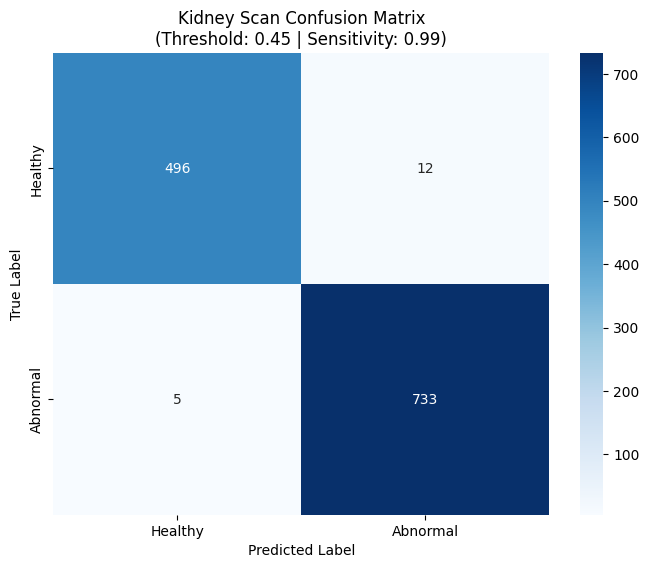


--- Detailed Classification Report ---
              precision    recall  f1-score   support

     Healthy       0.99      0.98      0.98       508
    Abnormal       0.98      0.99      0.99       738

    accuracy                           0.99      1246
   macro avg       0.99      0.98      0.99      1246
weighted avg       0.99      0.99      0.99      1246



In [22]:
## Confusion Matrix ##

from sklearn.metrics import recall_score

cm = confusion_matrix(all_labels, all_preds)

# calculating Sensitivity (Recall) 
sensitivity = recall_score(all_labels, all_preds)
print(f"Medical Sensitivity (Recall): {sensitivity:.4f}")

# plotting the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Healthy', 'Abnormal'], 
            yticklabels=['Healthy', 'Abnormal'])

plt.title(f'Kidney Scan Confusion Matrix\n(Threshold: {threshold} | Sensitivity: {sensitivity:.2f})')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# saving the image
plt.savefig('kidney_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()





# Classification report ##
print("\n--- Detailed Classification Report ---")
print(classification_report(all_labels, all_preds, target_names=['Healthy', 'Abnormal']))